slope min: 1.07 deg
slope max: 88.53 deg


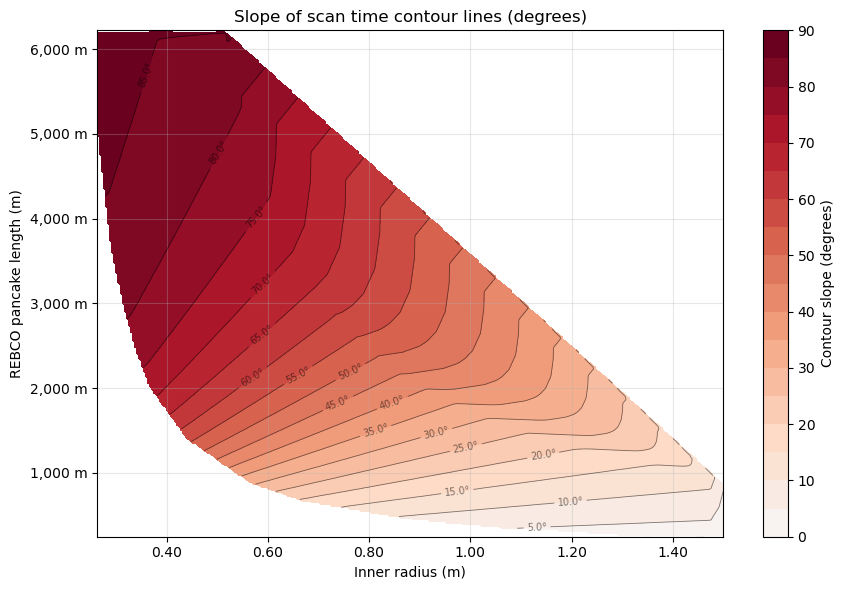

Configurations on iso-slope 10° (±2.0°): 92
 row_i  col_j       ri  rebco_pancake_length         scan  slope_deg
     1      0 0.010000            142.514570 7.151145e+11   9.693727
     1      4 0.111017            142.514570 3.667105e+05   9.141636
     2     13 0.338305            247.304896 9.129313e+02  10.967150
     2     14 0.363559            247.304896 7.395220e+02   9.991392
     2     15 0.388814            247.304896 6.087374e+02   9.175384
     2     16 0.414068            247.304896 5.080253e+02   8.483658
     3     20 0.515085            352.095221 1.389259e+02  11.687848
     3     21 0.540339            352.095221 1.212565e+02  11.045391
     3     22 0.565593            352.095221 1.065614e+02  10.470705
     3     23 0.590847            352.095221 9.422791e+01   9.953720
Saved to iso_slope_10deg_10000m.csv


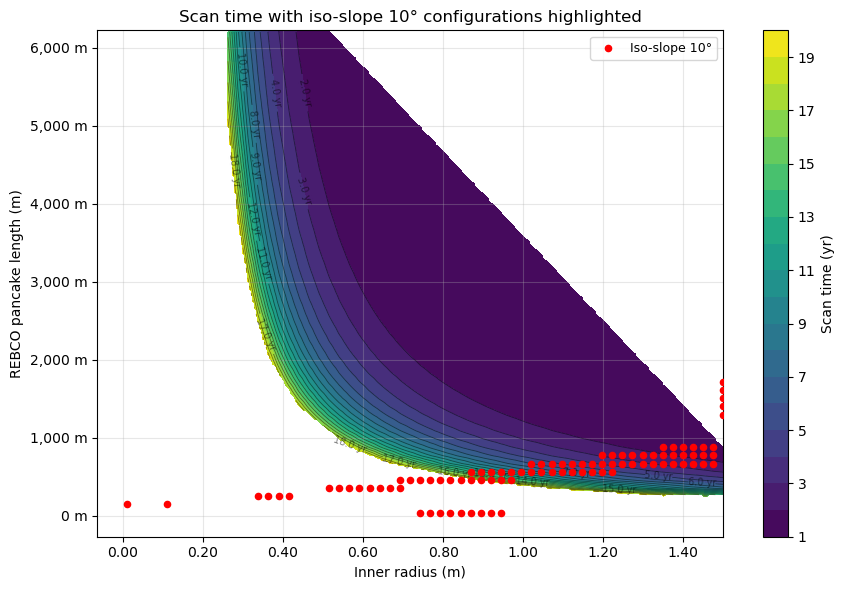

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

fname = 'area_grids_L5000mm.csv'
df_raw = pd.read_csv(fname)
df_raw.columns = df_raw.columns.str.strip()

cols_needed = ['row_i', 'col_j', 'ri', 'rebco_pancake_length', 'scan']
df = df_raw[cols_needed].copy()
df = df.dropna(subset=cols_needed)

# Get the sorted unique indices
row_indices = sorted(df['row_i'].unique())
col_indices = sorted(df['col_j'].unique())

n_rows = len(row_indices)
n_cols = len(col_indices)

# ── Allocate matrices ──────────────────────────────────────────────────────
mat_ri    = np.full((n_rows, n_cols), np.nan)
mat_pl    = np.full((n_rows, n_cols), np.nan)
mat_scan  = np.full((n_rows, n_cols), np.nan)
mat_dsdri = np.full((n_rows, n_cols), np.nan)   # dscan/dri
mat_dsdpl = np.full((n_rows, n_cols), np.nan)   # dscan/dpancake_length
mat_slope = np.full((n_rows, n_cols), np.nan)   # slope of contour line

# ── Fill matrices ──────────────────────────────────────────────────────────
for j_idx, j in enumerate(col_indices):
    for i_idx, i in enumerate(row_indices):
        cell = df[(df['row_i'] == i) & (df['col_j'] == j)]
        if not cell.empty:
            mat_ri  [i_idx, j_idx] = cell.iloc[0]['ri']
            mat_pl  [i_idx, j_idx] = cell.iloc[0]['rebco_pancake_length']
            mat_scan[i_idx, j_idx] = cell.iloc[0]['scan']

# ── ds horizontal: difference along col_j (x direction) ───────────────────
mat_ds_horizontal = np.full((n_rows, n_cols), np.nan)

for i_idx in range(n_rows):
    for j_idx in range(n_cols):
        if j_idx == 0:
            mat_ds_horizontal[i_idx, j_idx] = mat_scan[i_idx, j_idx + 1] - mat_scan[i_idx, j_idx]
        elif j_idx == n_cols - 1:
            mat_ds_horizontal[i_idx, j_idx] = mat_scan[i_idx, j_idx]     - mat_scan[i_idx, j_idx - 1]
        else:
            mat_ds_horizontal[i_idx, j_idx] = mat_scan[i_idx, j_idx + 1] - mat_scan[i_idx, j_idx - 1]

# ── ds vertical: difference along row_i (y direction) ─────────────────────
mat_ds_vertical = np.full((n_rows, n_cols), np.nan)

for j_idx in range(n_cols):
    for i_idx in range(n_rows):
        if i_idx == 0:
            mat_ds_vertical[i_idx, j_idx] = mat_scan[i_idx + 1, j_idx] - mat_scan[i_idx, j_idx]
        elif i_idx == n_rows - 1:
            mat_ds_vertical[i_idx, j_idx] = mat_scan[i_idx, j_idx]     - mat_scan[i_idx - 1, j_idx]
        else:
            mat_ds_vertical[i_idx, j_idx] = mat_scan[i_idx + 1, j_idx] - mat_scan[i_idx - 1, j_idx]

# ── Slope of the contour line ──────────────────────────────────────────────
mat_slope = np.degrees(np.arctan2(np.abs(mat_ds_horizontal), np.abs(mat_ds_vertical)))

# ── Flatten and filter ─────────────────────────────────────────────────────
x = mat_ri   .flatten()
y = mat_pl   .flatten()
z = mat_slope.flatten()
s = mat_scan .flatten()

mask = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))
mask = mask & (s >= 1) & (s <= 20)
x, y, z = x[mask], y[mask], z[mask]

print(f"slope min: {z.min():.2f} deg")
print(f"slope max: {z.max():.2f} deg")

# ── Interpolate onto regular grid ──────────────────────────────────────────
xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, y), z, (Xi, Yi), method='linear')

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

abs_max = np.nanmax(np.abs(z))
cf = ax.contourf(Xi, Yi, Zi, levels=20, cmap='RdBu_r',
                 vmin=-abs_max, vmax=abs_max)
cs = ax.contour(Xi, Yi, Zi, levels=20, colors='k', linewidths=0.6, alpha=0.5)
ax.clabel(cs, fmt='%.1f°', fontsize=7, inline=True)

plt.colorbar(cf, ax=ax, label='Contour slope (degrees)')

ax.set_xlabel('Inner radius (m)')
ax.set_ylabel('REBCO pancake length (m)')
ax.set_title('Slope of scan time contour lines (degrees)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f} m'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('contour_slope_10000m.png', dpi=150, bbox_inches='tight')
plt.show()



x# ── Select configurations near iso-slope of 10 degrees ────────────────────
tolerance = 2.0   # ± degrees around 10°

rows_out = []

for j_idx, j in enumerate(col_indices):
    for i_idx, i in enumerate(row_indices):

        slope_val = mat_slope[i_idx, j_idx]
        scan_val  = mat_scan [i_idx, j_idx]
        ri_val    = mat_ri   [i_idx, j_idx]
        pl_val    = mat_pl   [i_idx, j_idx]

        if np.isnan(slope_val) or np.isnan(scan_val):
            continue

        if abs(slope_val - 10.0) <= tolerance:
            rows_out.append({
                'row_i'               : i,
                'col_j'               : j,
                'ri'                  : ri_val,
                'rebco_pancake_length': pl_val,
                'scan'                : scan_val,
                'slope_deg'           : slope_val,
            })

df_iso = pd.DataFrame(rows_out)
df_iso = df_iso.sort_values(['ri', 'rebco_pancake_length']).reset_index(drop=True)

print(f"Configurations on iso-slope 10° (±{tolerance}°): {len(df_iso)}")
print(df_iso.head(10).to_string(index=False))

df_iso.to_csv('iso_slope_10deg_10000m.csv', index=False)
print("Saved to iso_slope_10deg_10000m.csv")


# ── Overlay iso-slope 10° points on scan contour plot ─────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 6))

# Replot scan contour
x_s = mat_ri  .flatten()
y_s = mat_pl  .flatten()
z_s = mat_scan.flatten()
s_s = mat_scan.flatten()

mask_s = ~(np.isnan(x_s) | np.isnan(y_s) | np.isnan(z_s))
mask_s = mask_s & (s_s >= 1) & (s_s <= 20)
x_s, y_s, z_s = x_s[mask_s], y_s[mask_s], z_s[mask_s]

xi_s = np.linspace(x_s.min(), x_s.max(), 300)
yi_s = np.linspace(y_s.min(), y_s.max(), 300)
Xi_s, Yi_s = np.meshgrid(xi_s, yi_s)
Zi_s = griddata((x_s, y_s), z_s, (Xi_s, Yi_s), method='linear')

cf2 = ax2.contourf(Xi_s, Yi_s, Zi_s, levels=20, cmap='viridis')
cs2 = ax2.contour(Xi_s, Yi_s, Zi_s, levels=20, colors='k', linewidths=0.6, alpha=0.5)
ax2.clabel(cs2, fmt='%.1f yr', fontsize=7, inline=True)
plt.colorbar(cf2, ax=ax2, label='Scan time (yr)')

# ── Overlay iso-slope points ───────────────────────────────────────────────
ax2.scatter(df_iso['ri'], df_iso['rebco_pancake_length'],
            c='red', s=20, zorder=5, label='Iso-slope 10°')
ax2.legend(fontsize=9)

ax2.set_xlabel('Inner radius (m)')
ax2.set_ylabel('REBCO pancake length (m)')
ax2.set_title('Scan time with iso-slope 10° configurations highlighted')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2f}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f} m'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scan_with_iso_slope_10deg.png', dpi=150, bbox_inches='tight')
plt.show()

Global x (ri):            0.176 – 1.500 m
Global y (pancake len):   725 – 6220 m
n_pancakes: {'1m': 250.0, '2m': 500.0, '3m': 750.0, '4m': 1000.0, '5m': 1250.0, '6m': 1500.0, '7m': 1750.0, '8m': 2000.0, '9m': 2250.0, '10m': 2500.0}
Global total REBCO len:   543512 – 15550884 m


/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_33931/1870642620.py:182: UserWarning: Adding colorbar to a different Figure <Figure size 3000x1000 with 11 Axes> than <Figure size 3000x1000 with 10 Axes> which fig.colorbar is called on.
  plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_33931/1870642620.py:182: UserWarning: Adding colorbar to a different Figure <Figure size 3000x1000 with 12 Axes> than <Figure size 3000x1000 with 11 Axes> which fig.colorbar is called on.
  plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_33931/1870642620.py:182: UserWarning: Adding colorbar to a different Figure <Figure size 3000x1000 with 13 Axes> than <Figure size 3000x1000 with 12 Axes> which fig.colorbar is called on.
  plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_33931/1870642620.

KeyError: 'length'

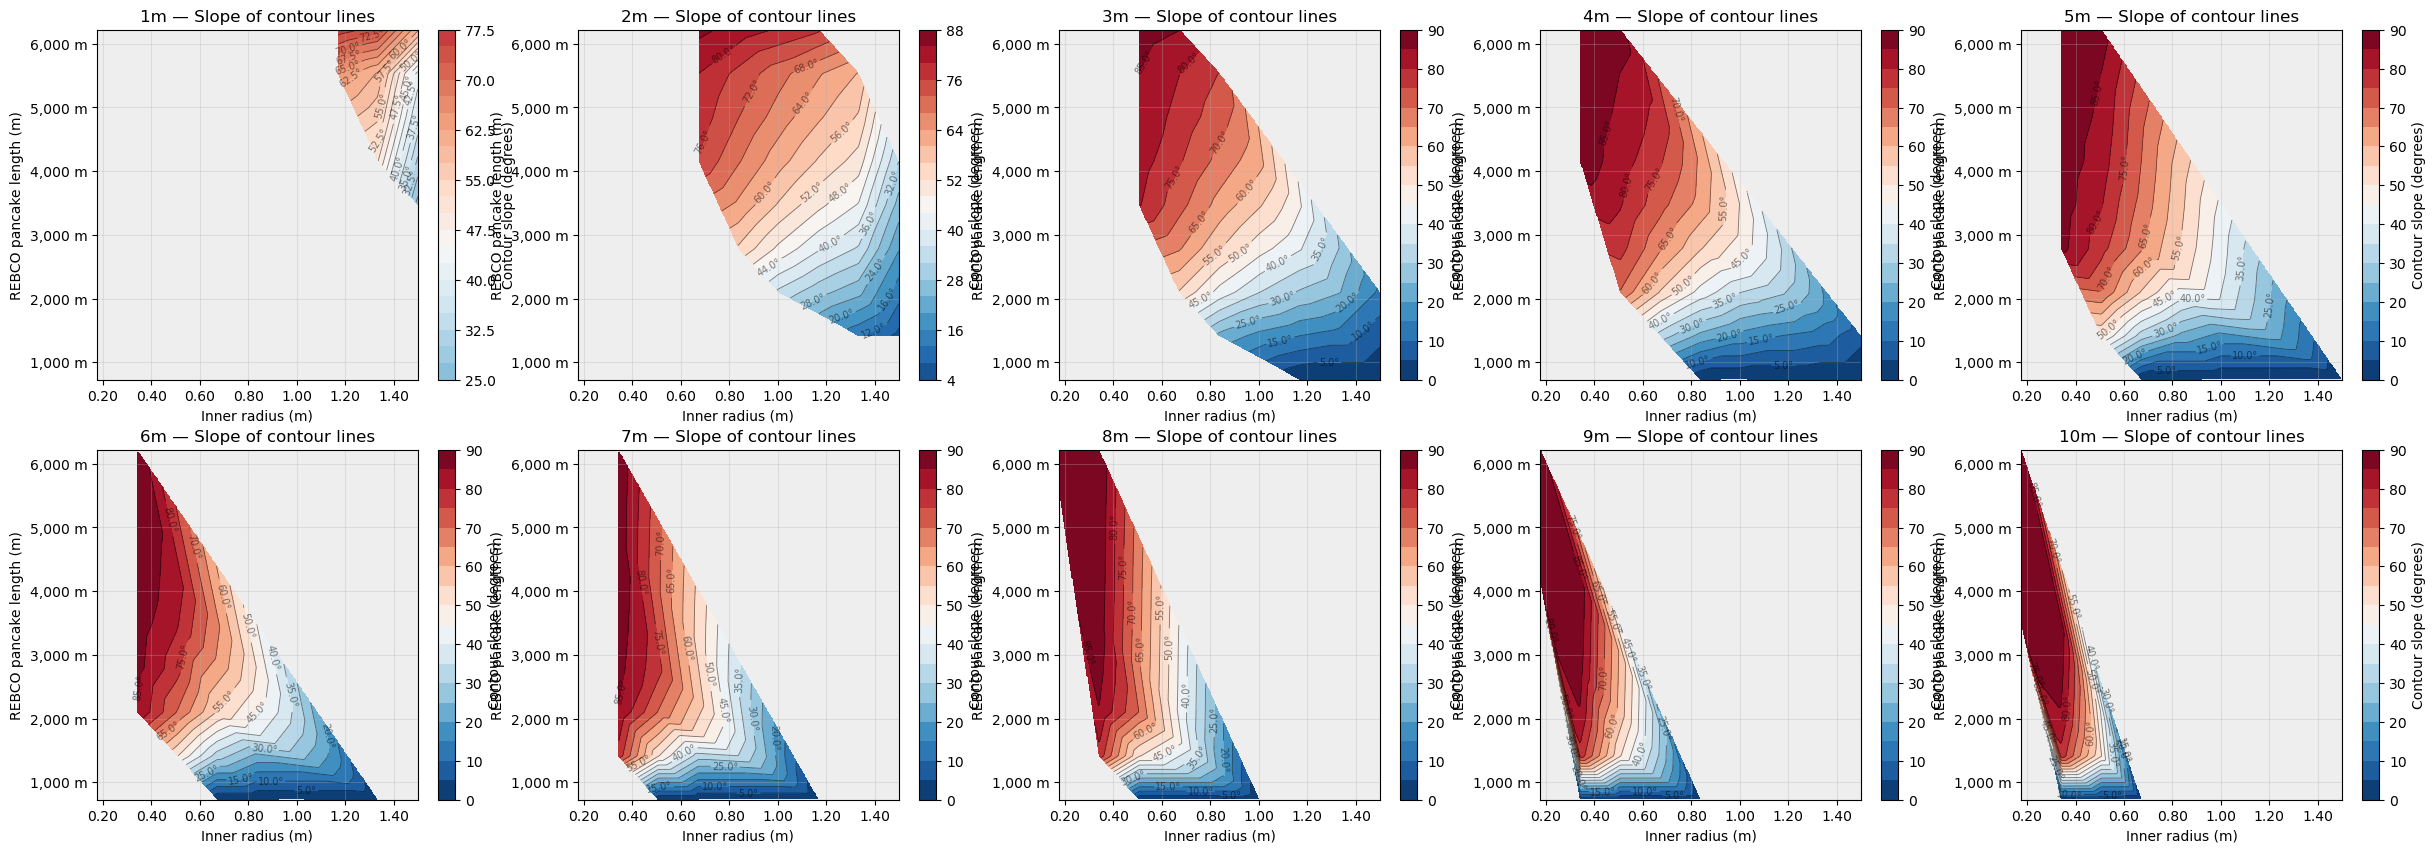

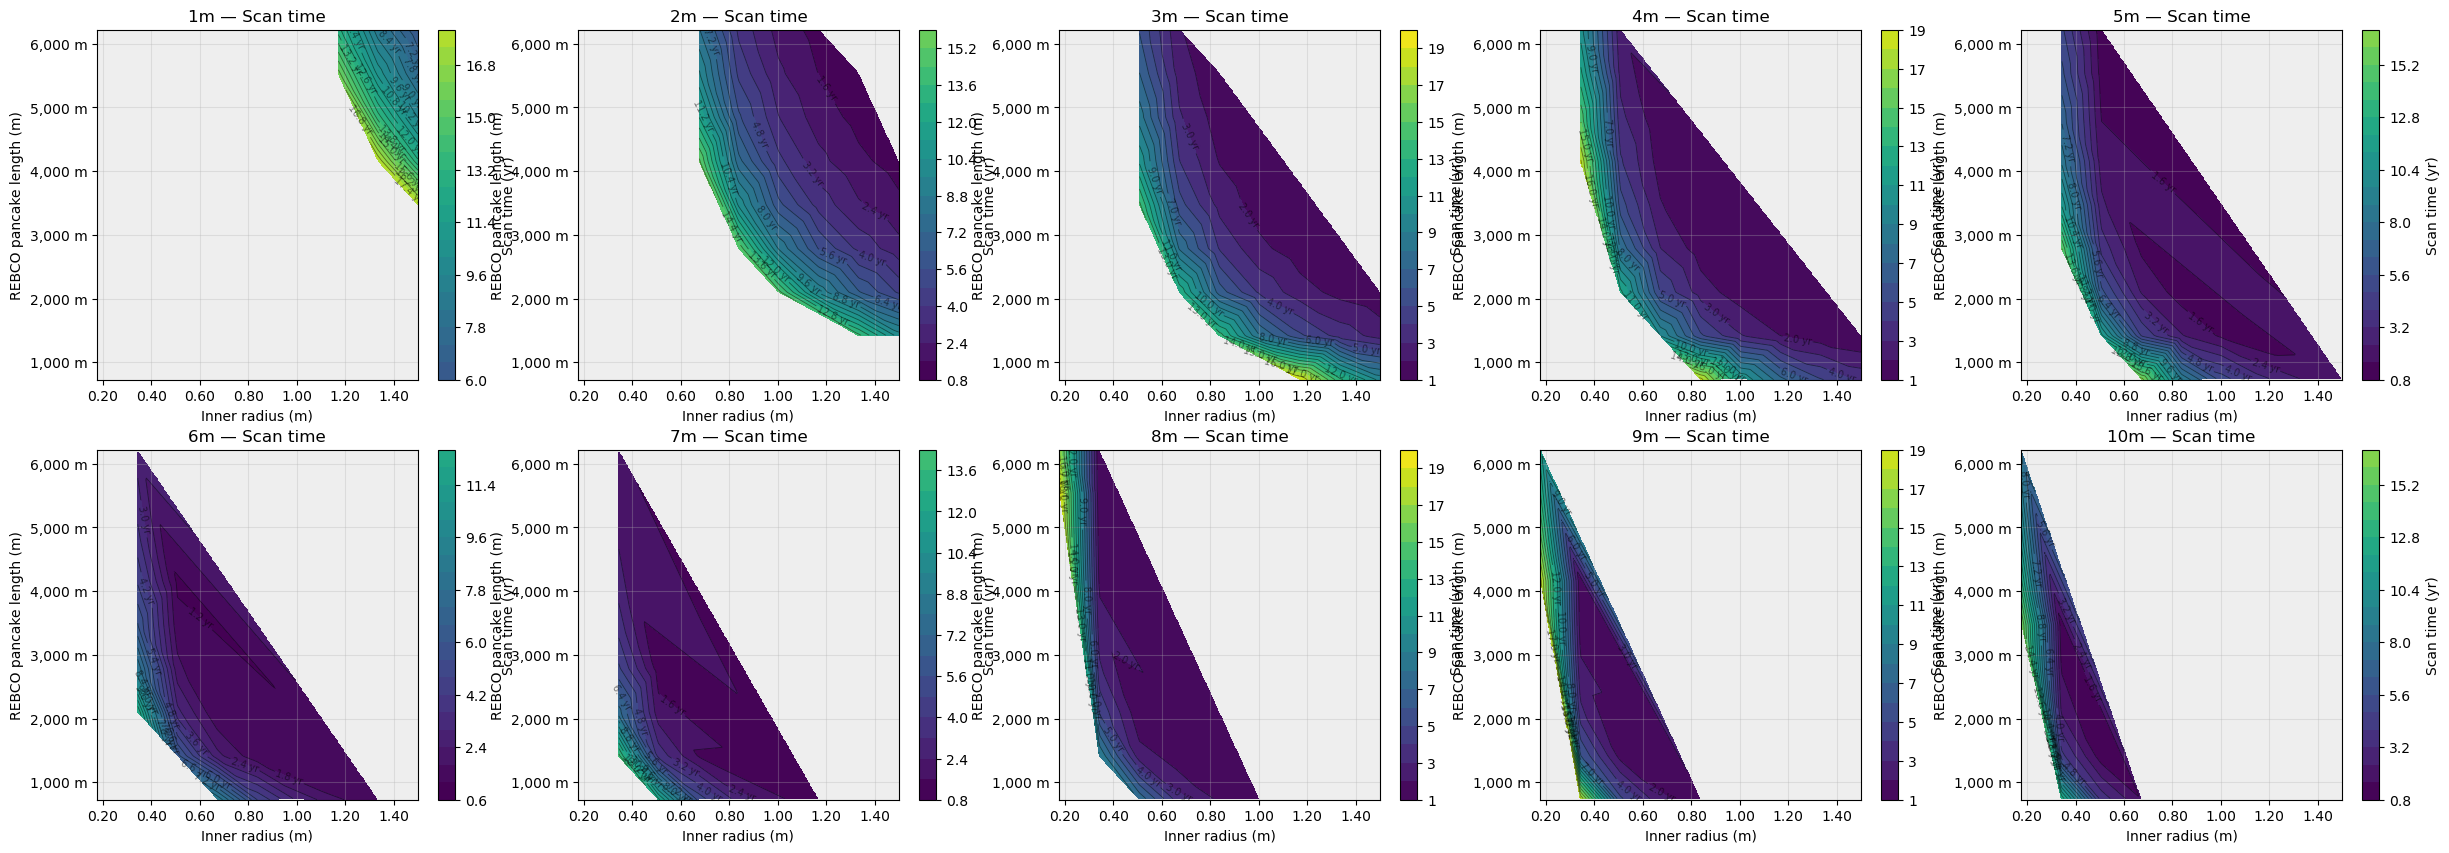

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import Delaunay

files = {
    '1m' : ('area_grids_L1000mm.csv',   250),
    '2m' : ('area_grids_L2000mm.csv',   500),
    '3m' : ('area_grids_L3000mm.csv',   750),
    '4m' : ('area_grids_L4000mm.csv',  1000),
    '5m' : ('area_grids_L5000mm.csv',  1250),
    '6m' : ('area_grids_L6000mm.csv',  1500),
    '7m' : ('area_grids_L7000mm.csv',  1750),
    '8m' : ('area_grids_L8000mm.csv',  2000),
    '9m' : ('area_grids_L9000mm.csv',  2250),
    '10m': ('area_grids_L10000mm.csv', 2500),
}

colors = {
    '1m' : 'steelblue',
    '2m' : 'darkorange',
    '3m' : 'lightcoral',
    '4m' : 'gold',
    '5m' : 'seagreen',
    '6m' : 'mediumpurple',
    '7m' : 'darkcyan',
    '8m' : 'darkmagenta',
    '9m' : 'sienna',
    '10m': 'crimson',
}

rebco_thickness = 0.004  # 4 mm per pancake → n_pancakes = solenoid_length / thickness

n_pancakes = {
    label: int(label.replace('m', '')) / rebco_thickness
    for label in files
}

tolerance = 0.3  # ± degrees around 20°

# ── Compute global axis limits across all files ────────────────────────────
x_all, y_all = [], []
for fname, _ in files.values():
    df_tmp = pd.read_csv(fname)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp = df_tmp[['ri', 'rebco_pancake_length', 'scan']].dropna()
    df_tmp = df_tmp[(df_tmp['scan'] >= 1) & (df_tmp['scan'] <= 20)]
    x_all.append(df_tmp['ri'].values)
    y_all.append(df_tmp['rebco_pancake_length'].values)

x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

x_min, x_max = x_all.min(), x_all.max()
y_min, y_max = y_all.min(), y_all.max()

# ── Compute global total-REBCO-length limits ───────────────────────────────
total_len_all = []
for label, (fname, _) in files.items():
    df_tmp = pd.read_csv(fname)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp = df_tmp[['rebco_pancake_length', 'scan']].dropna()
    df_tmp = df_tmp[(df_tmp['scan'] >= 1) & (df_tmp['scan'] <= 20)]
    total_len_all.append(df_tmp['rebco_pancake_length'].values * n_pancakes[label])

total_len_all = np.concatenate(total_len_all)
tl_min, tl_max = total_len_all.min(), total_len_all.max()

print(f"Global x (ri):            {x_min:.3f} – {x_max:.3f} m")
print(f"Global y (pancake len):   {y_min:.0f} – {y_max:.0f} m")
print(f"n_pancakes: {n_pancakes}")
print(f"Global total REBCO len:   {tl_min:.0f} – {tl_max:.0f} m")

# ── Figures (2×5 grid for 10 magnet lengths) ──────────────────────────────
fig1, axes1 = plt.subplots(2, 5, figsize=(30, 10))
fig2, axes2 = plt.subplots(2, 5, figsize=(30, 10))
axes1 = axes1.flatten()
axes2 = axes2.flatten()

all_iso = []

for idx, (label, (fname, _)) in enumerate(files.items()):

    # ── Load ───────────────────────────────────────────────────────────────
    df_raw = pd.read_csv(fname)
    df_raw.columns = df_raw.columns.str.strip()

    cols_needed = ['row_i', 'col_j', 'ri', 'rebco_pancake_length', 'scan']
    df = df_raw[cols_needed].copy()
    df = df.dropna(subset=cols_needed)

    row_indices = sorted(df['row_i'].unique())
    col_indices = sorted(df['col_j'].unique())

    # ── Fill matrices (fast pivot) ─────────────────────────────────────────
    mat_ri   = df.pivot(index='row_i', columns='col_j', values='ri').values
    mat_pl   = df.pivot(index='row_i', columns='col_j', values='rebco_pancake_length').values
    mat_scan = df.pivot(index='row_i', columns='col_j', values='scan').values

    n_rows, n_cols = mat_scan.shape

    # ── ds horizontal (central differences) ───────────────────────────────
    mat_ds_horizontal = np.full((n_rows, n_cols), np.nan)
    mat_ds_horizontal[:, 0]    = mat_scan[:, 1]  - mat_scan[:, 0]
    mat_ds_horizontal[:, -1]   = mat_scan[:, -1] - mat_scan[:, -2]
    mat_ds_horizontal[:, 1:-1] = mat_scan[:, 2:] - mat_scan[:, :-2]

    # ── ds vertical (central differences) ─────────────────────────────────
    mat_ds_vertical = np.full((n_rows, n_cols), np.nan)
    mat_ds_vertical[0, :]    = mat_scan[1, :]  - mat_scan[0, :]
    mat_ds_vertical[-1, :]   = mat_scan[-1, :] - mat_scan[-2, :]
    mat_ds_vertical[1:-1, :] = mat_scan[2:, :] - mat_scan[:-2, :]

    # ── Slope ──────────────────────────────────────────────────────────────
    mat_slope = np.degrees(np.arctan2(np.abs(mat_ds_horizontal), np.abs(mat_ds_vertical)))

    # ── Flatten and mask ───────────────────────────────────────────────────
    x       = mat_ri   .flatten()
    y       = mat_pl   .flatten()
    z_slope = mat_slope.flatten()
    z_scan  = mat_scan .flatten()

    mask = (~(np.isnan(x) | np.isnan(y) | np.isnan(z_slope) | np.isnan(z_scan))
            & (z_scan >= 1) & (z_scan <= 20))
    x_m       = x[mask]
    y_m       = y[mask]
    z_slope_m = z_slope[mask]
    z_scan_m  = z_scan [mask]

    # ── Interpolate onto global grid ───────────────────────────────────────
    xi = np.linspace(x_min, x_max, 300)
    yi = np.linspace(y_min, y_max, 300)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi_slope = griddata((x_m, y_m), z_slope_m, (Xi, Yi), method='linear')
    Zi_scan  = griddata((x_m, y_m), z_scan_m,  (Xi, Yi), method='linear')

    # ── Mask outside convex hull ───────────────────────────────────────────
    points      = np.column_stack([x_m, y_m])
    hull        = Delaunay(points)
    grid_points = np.column_stack([Xi.ravel(), Yi.ravel()])
    outside     = hull.find_simplex(grid_points) < 0

    Zi_slope.ravel()[outside] = np.nan
    Zi_scan .ravel()[outside] = np.nan

    # ── Iso-slope 20° points ───────────────────────────────────────────────
    rows_out = []
    for i_idx, i in enumerate(row_indices):
        for j_idx, j in enumerate(col_indices):
            slope_val = mat_slope[i_idx, j_idx]
            scan_val  = mat_scan [i_idx, j_idx]
            ri_val    = mat_ri   [i_idx, j_idx]
            pl_val    = mat_pl   [i_idx, j_idx]

            if np.isnan(slope_val) or np.isnan(scan_val):
                continue
            if not (1 <= scan_val <= 20):
                continue
            if abs(slope_val - 10.0) <= tolerance:
                rows_out.append({
                    'length'              : label,
                    'row_i'               : i,
                    'col_j'               : j,
                    'ri'                  : ri_val,
                    'rebco_pancake_length': pl_val,
                    'rebco_total_length'  : pl_val * n_pancakes[label],
                    'scan'                : scan_val,
                    'slope_deg'           : slope_val,
                })

    df_iso = pd.DataFrame(rows_out)
    all_iso.append(df_iso)

    # ── Plot slope contour (fig1) ──────────────────────────────────────────
    ax1 = axes1[idx]
    ax1.set_facecolor('#eeeeee')
    cf1 = ax1.contourf(Xi, Yi, Zi_slope, levels=20, cmap='RdBu_r', vmin=0, vmax=90)
    cs1 = ax1.contour (Xi, Yi, Zi_slope, levels=20, colors='k', linewidths=0.6, alpha=0.5)
    ax1.clabel(cs1, fmt='%.1f°', fontsize=7, inline=True)
    plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')

    if not df_iso.empty:
        ax1.scatter(df_iso['ri'], df_iso['rebco_pancake_length'],
                    c='red', s=20, zorder=5, label=f'Iso-slope 20° (±{tolerance}°)')
        ax1.legend(fontsize=8)

    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_xlabel('Inner radius (m)')
    ax1.set_ylabel('REBCO pancake length (m)')
    ax1.set_title(f'{label} — Slope of contour lines')
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2f}'))
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f} m'))
    ax1.grid(True, alpha=0.3)

    # ── Plot scan contour (fig2) ───────────────────────────────────────────
    ax2 = axes2[idx]
    ax2.set_facecolor('#eeeeee')
    cf2 = ax2.contourf(Xi, Yi, Zi_scan, levels=20, cmap='viridis', vmin=1, vmax=20)
    cs2 = ax2.contour (Xi, Yi, Zi_scan, levels=20, colors='k', linewidths=0.6, alpha=0.5)
    ax2.clabel(cs2, fmt='%.1f yr', fontsize=7, inline=True)
    plt.colorbar(cf2, ax=ax2, label='Scan time (yr)')

    if not df_iso.empty:
        ax2.scatter(df_iso['ri'], df_iso['rebco_pancake_length'],
                    c='red', s=20, zorder=5, label=f'Iso-slope 20° (±{tolerance}°)')
        ax2.legend(fontsize=8)

    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_xlabel('Inner radius (m)')
    ax2.set_ylabel('REBCO pancake length (m)')
    ax2.set_title(f'{label} — Scan time')
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2f}'))
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f} m'))
    ax2.grid(True, alpha=0.3)

# ── Combine all iso-slope points ──────────────────────────────────────────
df_all_iso = pd.concat(all_iso, ignore_index=True)
df_all_iso = df_all_iso.rename(columns={'solenoid_length_m': 'length'})
df_all_iso = df_all_iso.sort_values(['length', 'ri', 'rebco_pancake_length']).reset_index(drop=True)
df_all_iso.to_csv('iso_slope_20deg_all_lengths.csv', index=False)
print(f"Total iso-slope points saved: {len(df_all_iso)}")
print(df_all_iso.groupby('length').size())

fig1.suptitle('Slope of scan time contour lines with iso-slope 20° highlighted', fontsize=13)
fig1.tight_layout()
fig1.savefig('slope_contour_all_lengths.png', dpi=150, bbox_inches='tight')

fig2.suptitle('Scan time with iso-slope 20° highlighted', fontsize=13)
fig2.tight_layout()
fig2.savefig('scan_contour_all_lengths.png', dpi=150, bbox_inches='tight')

plt.show()

# ── fig3: Scan time vs REBCO pancake length ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 6))

for label in files.keys():
    subset = df_all_iso[df_all_iso['length'] == label]
    if subset.empty:
        continue
    ax3.scatter(subset['rebco_pancake_length'], subset['scan'],
                color=colors[label], s=20, alpha=0.7, label=label)

ax3.set_xlabel('REBCO pancake length (m)')
ax3.set_ylabel('Scan time (yr)')
ax3.set_title('Scan time vs REBCO pancake length\n(iso-slope 20° configurations)')
ax3.legend(title='Magnet length', fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_rebco_pancake_length_iso20.png', dpi=150, bbox_inches='tight')
plt.show()

# ── fig4: Scan time vs TOTAL REBCO length ────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 6))

for label in files.keys():
    subset = df_all_iso[df_all_iso['length'] == label]
    if subset.empty:
        continue
    ax4.scatter(subset['rebco_total_length'] / 1e3, subset['scan'],
                color=colors[label], s=20, alpha=0.7, label=label)

ax4.set_xlabel('REBCO total length (km)')
ax4.set_ylabel('Scan time (yr)')
ax4.set_title('Scan time vs REBCO total length\n(iso-slope 20° configurations)')
ax4.legend(title='Magnet length', fontsize=9)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_rebco_total_length_iso20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nn_pancakes per configuration:")
for label, np_ in n_pancakes.items():
    print(f"  {label}: {np_:.0f} pancakes")

print("\nTotal REBCO length range per magnet length:")
print(df_all_iso.groupby('length')['rebco_total_length'].agg(['min', 'max']).round(0))
print(f"\nOverall REBCO total length range:")
print(f"  Min: {df_all_iso['rebco_total_length'].min()/1e3:.1f} km")
print(f"  Max: {df_all_iso['rebco_total_length'].max()/1e3:.1f} km")


# ── fig3: Scan time vs REBCO pancake length ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 6))

for label in files.keys():
    subset = df_all_iso[df_all_iso['length'] == label]
    if subset.empty:
        continue
    subset = subset.sort_values('rebco_pancake_length')
    ax3.plot(subset['rebco_pancake_length'], subset['scan'],
              color=colors[label], marker='o', markersize=5,
              linewidth=1.5, alpha=0.8, label=label)

ax3.set_xlabel('REBCO pancake length (m)')
ax3.set_ylabel('Scan time (yr)')
ax3.set_title('Scan time vs REBCO pancake length\n(iso-slope 20° configurations)')
ax3.legend(title='Magnet length', fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_rebco_pancake_length_iso20.png', dpi=150, bbox_inches='tight')
plt.show()

# ── fig4: Scan time vs TOTAL REBCO length ────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 6))

for label in files.keys():
    subset = df_all_iso[df_all_iso['length'] == label]
    if subset.empty:
        continue
    subset = subset.sort_values('rebco_total_length')
    ax4.plot(subset['rebco_total_length'] / 1e3, subset['scan'],
              color=colors[label], marker='o', markersize=5,
              linewidth=1.5, alpha=0.8, label=label)

ax4.set_xlabel('REBCO total length (km)')
ax4.set_ylabel('Scan time (yr)')
ax4.set_title('Scan time vs REBCO total length\n(iso-slope 20° configurations)')
ax4.legend(title='Magnet length', fontsize=9)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_rebco_total_length_iso20.png', dpi=150, bbox_inches='tight')
plt.show()



Global x (ri):            0.164 – 1.500 m
Global y (pancake len):   251 – 6220 m
n_pancakes: {'1m': 250.0, '2m': 500.0, '3m': 750.0, '4m': 1000.0, '5m': 1250.0, '6m': 1500.0, '7m': 1750.0, '8m': 2000.0, '9m': 2250.0, '10m': 2500.0}
Global total REBCO len:   376378 – 15550884 m


/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_34852/1084972854.py:196: UserWarning: Adding colorbar to a different Figure <Figure size 3000x1000 with 11 Axes> than <Figure size 3000x1000 with 10 Axes> which fig.colorbar is called on.
  plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_34852/1084972854.py:196: UserWarning: Adding colorbar to a different Figure <Figure size 3000x1000 with 12 Axes> than <Figure size 3000x1000 with 11 Axes> which fig.colorbar is called on.
  plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_34852/1084972854.py:196: UserWarning: Adding colorbar to a different Figure <Figure size 3000x1000 with 13 Axes> than <Figure size 3000x1000 with 12 Axes> which fig.colorbar is called on.
  plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')
/var/folders/8k/rnt65xzx4ml1894t3n7wmjzw0000gn/T/ipykernel_34852/1084972854.

Total iso-slope points saved: 61
length
10m    17
6m      6
7m     10
8m     13
9m     15
dtype: int64


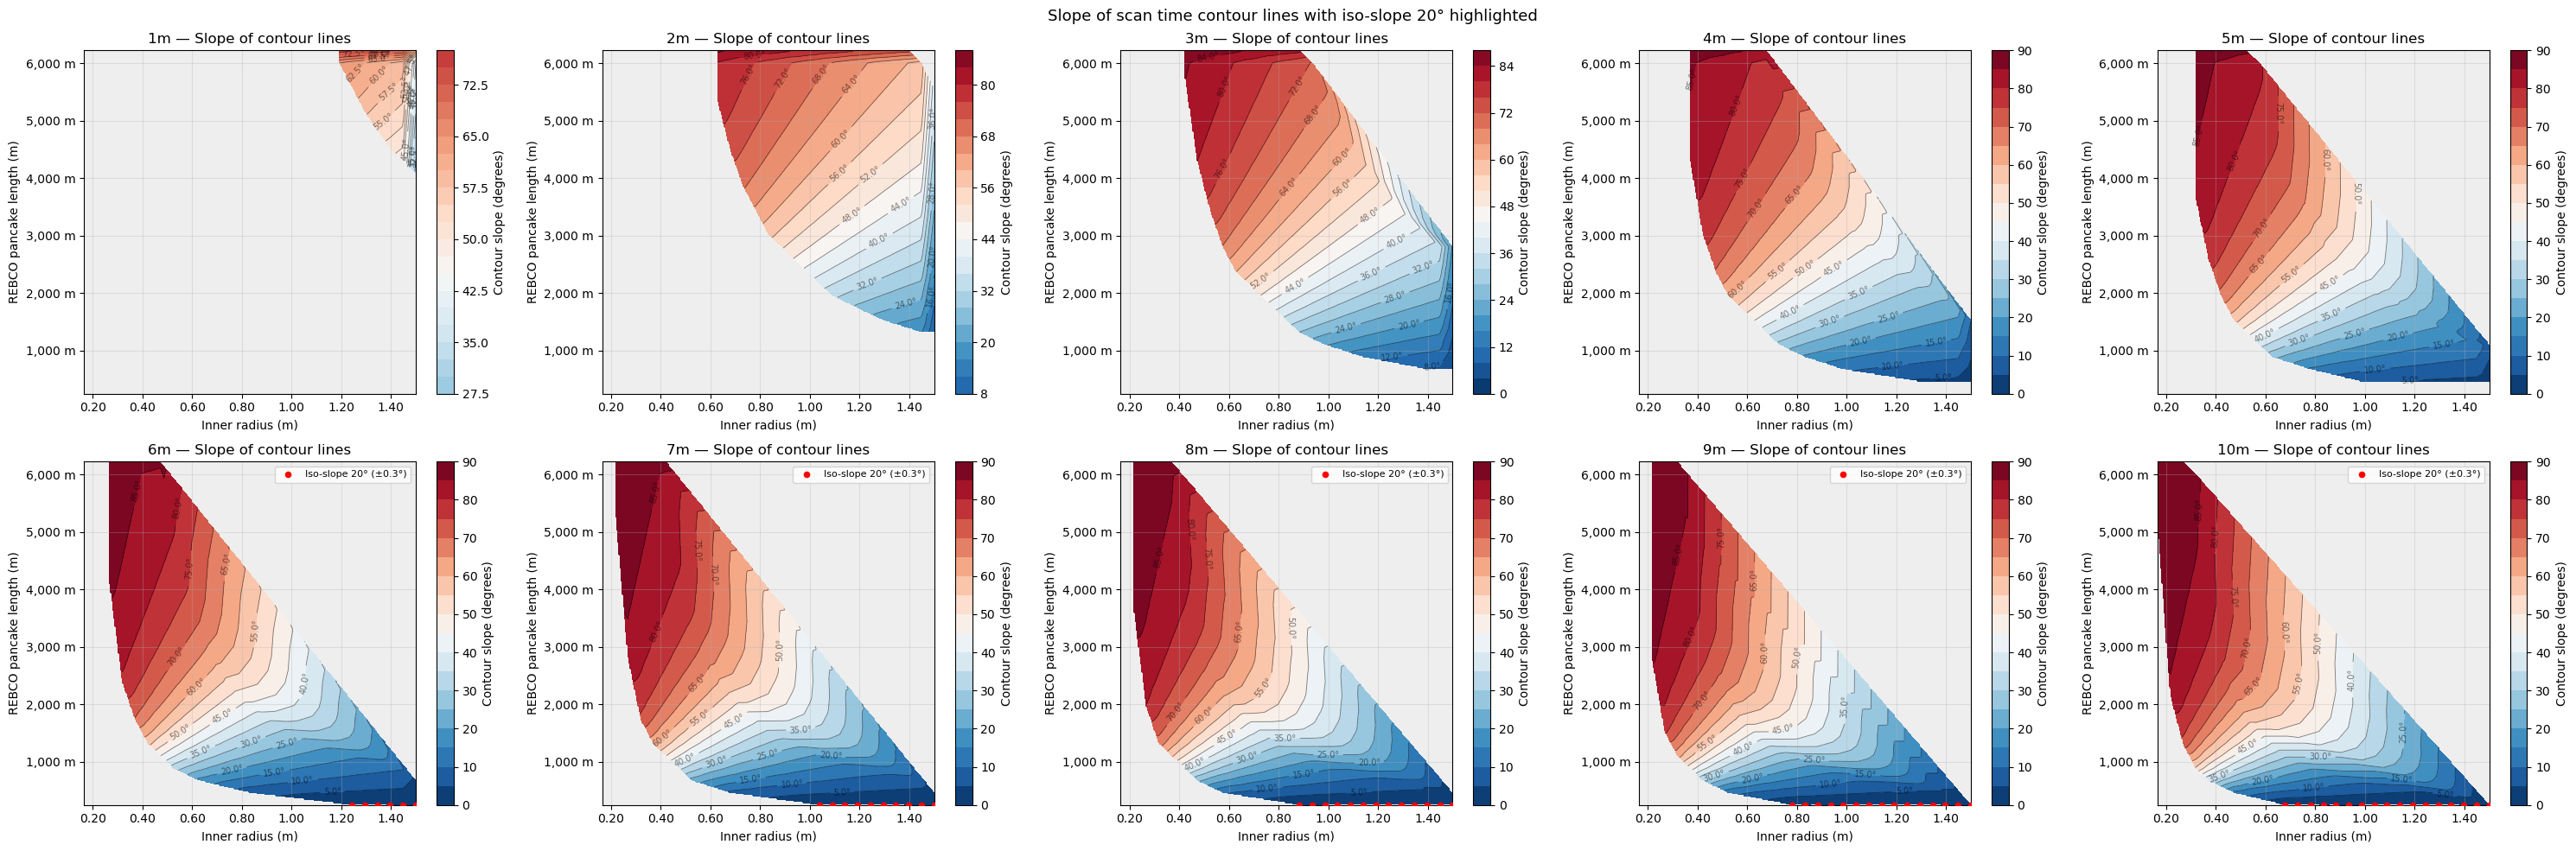

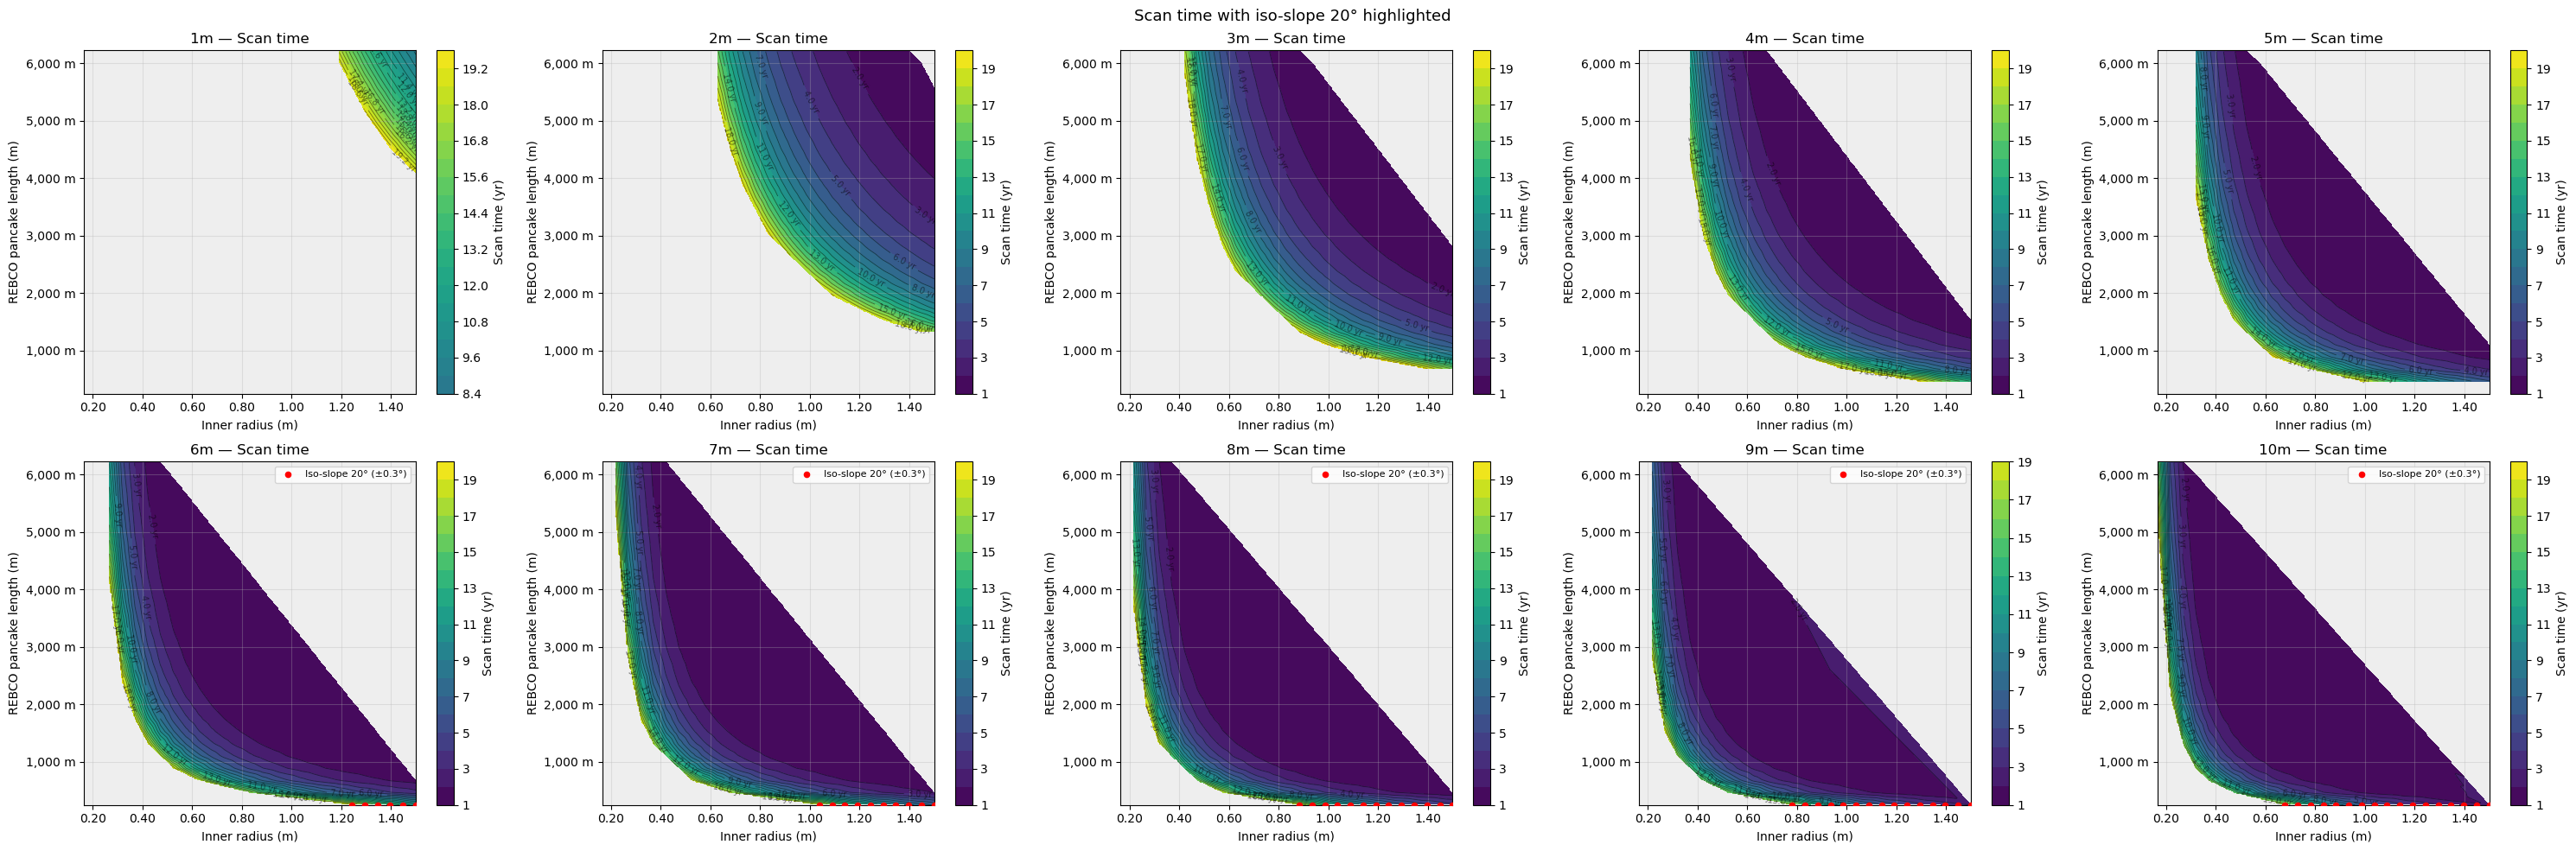

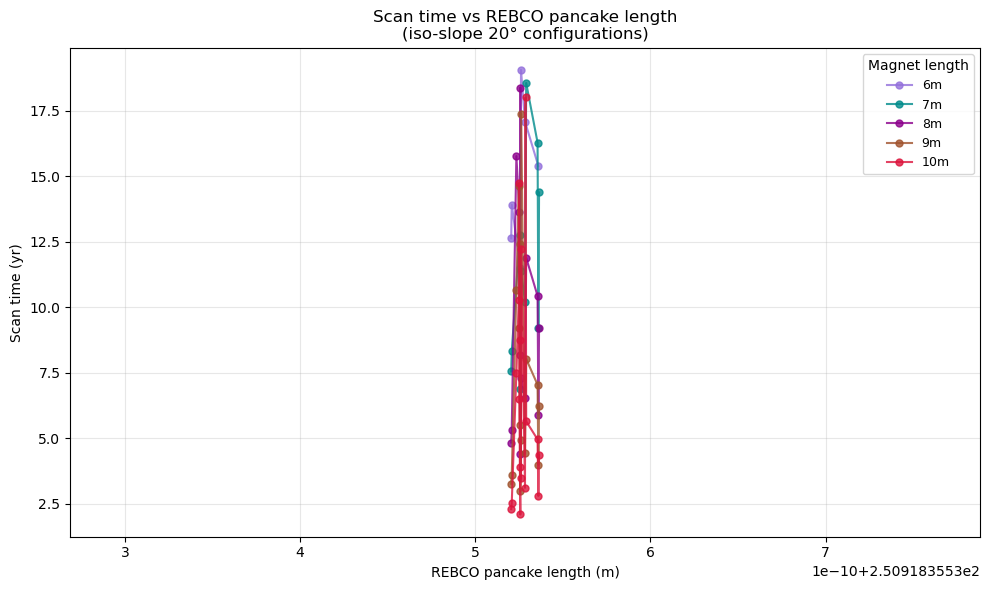

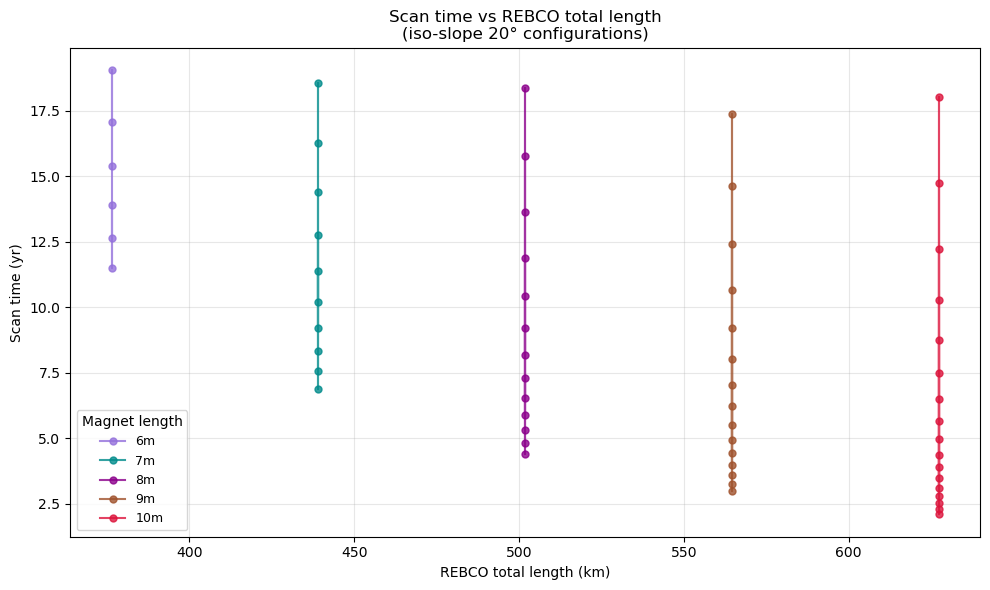


n_pancakes per configuration:
  1m: 250 pancakes
  2m: 500 pancakes
  3m: 750 pancakes
  4m: 1000 pancakes
  5m: 1250 pancakes
  6m: 1500 pancakes
  7m: 1750 pancakes
  8m: 2000 pancakes
  9m: 2250 pancakes
  10m: 2500 pancakes

Total REBCO length range per magnet length:
             min       max
length                    
10m     627296.0  627296.0
6m      376378.0  376378.0
7m      439107.0  439107.0
8m      501837.0  501837.0
9m      564566.0  564566.0

Overall REBCO total length range:
  Min: 376.4 km
  Max: 627.3 km


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.spatial import Delaunay

files = {
    '1m' : ('area_grids_L1000mm.csv',   250),
    '2m' : ('area_grids_L2000mm.csv',   500),
    '3m' : ('area_grids_L3000mm.csv',   750),
    '4m' : ('area_grids_L4000mm.csv',  1000),
    '5m' : ('area_grids_L5000mm.csv',  1250),
    '6m' : ('area_grids_L6000mm.csv',  1500),
    '7m' : ('area_grids_L7000mm.csv',  1750),
    '8m' : ('area_grids_L8000mm.csv',  2000),
    '9m' : ('area_grids_L9000mm.csv',  2250),
    '10m': ('area_grids_L10000mm.csv', 2500),
}

colors = {
    '1m' : 'steelblue',
    '2m' : 'darkorange',
    '3m' : 'lightcoral',
    '4m' : 'gold',
    '5m' : 'seagreen',
    '6m' : 'mediumpurple',
    '7m' : 'darkcyan',
    '8m' : 'darkmagenta',
    '9m' : 'sienna',
    '10m': 'crimson',
}

rebco_thickness = 0.004  # 4 mm per pancake → n_pancakes = solenoid_length / thickness

n_pancakes = {
    label: int(label.replace('m', '')) / rebco_thickness
    for label in files
}

tolerance = 0.3  # ± degrees around 20°

# all columns present in each area_grids_LXXX.csv
all_cols = ['row_i', 'col_j', 'solenoid_length_m', 'ri', 'rf', 'th', 'a', 'a_sc',
            'v', 'v_bore', 'b0', 'scan', 'je_sc', 'je_max', 'stress',
            'rebco_pancake_length', 'rebco_total_length', 'j_crit', 'margin', 'converged']

# ── Compute global axis limits across all files ────────────────────────────
x_all, y_all = [], []
for fname, _ in files.values():
    df_tmp = pd.read_csv(fname)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp = df_tmp[['ri', 'rebco_pancake_length', 'scan']].dropna()
    df_tmp = df_tmp[(df_tmp['scan'] >= 1) & (df_tmp['scan'] <= 20)]
    x_all.append(df_tmp['ri'].values)
    y_all.append(df_tmp['rebco_pancake_length'].values)

x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

x_min, x_max = x_all.min(), x_all.max()
y_min, y_max = y_all.min(), y_all.max()

# ── Compute global total-REBCO-length limits ───────────────────────────────
total_len_all = []
for label, (fname, _) in files.items():
    df_tmp = pd.read_csv(fname)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp = df_tmp[['rebco_total_length', 'scan']].dropna()
    df_tmp = df_tmp[(df_tmp['scan'] >= 1) & (df_tmp['scan'] <= 20)]
    total_len_all.append(df_tmp['rebco_total_length'].values)

total_len_all = np.concatenate(total_len_all)
tl_min, tl_max = total_len_all.min(), total_len_all.max()

print(f"Global x (ri):            {x_min:.3f} – {x_max:.3f} m")
print(f"Global y (pancake len):   {y_min:.0f} – {y_max:.0f} m")
print(f"n_pancakes: {n_pancakes}")
print(f"Global total REBCO len:   {tl_min:.0f} – {tl_max:.0f} m")

# ── Figures (2×5 grid for 10 magnet lengths) ──────────────────────────────
fig1, axes1 = plt.subplots(2, 5, figsize=(30, 10))
fig2, axes2 = plt.subplots(2, 5, figsize=(30, 10))
axes1 = axes1.flatten()
axes2 = axes2.flatten()

all_iso = []

for idx, (label, (fname, _)) in enumerate(files.items()):

    # ── Load ───────────────────────────────────────────────────────────────
    df_raw = pd.read_csv(fname)
    df_raw.columns = df_raw.columns.str.strip()

    missing = [c for c in all_cols if c not in df_raw.columns]
    if missing:
        raise ValueError(f"{fname} is missing columns: {missing}")

    df = df_raw[all_cols].copy()
    df = df.dropna(subset=['row_i', 'col_j', 'ri', 'rebco_pancake_length', 'scan'])

    row_indices = sorted(df['row_i'].unique())
    col_indices = sorted(df['col_j'].unique())

    # ── Pivot every column into its own matrix ─────────────────────────────
    mat = {}
    for col in all_cols:
        if col in ('row_i', 'col_j'):
            continue
        mat[col] = df.pivot(index='row_i', columns='col_j', values=col).values

    mat_ri   = mat['ri']
    mat_pl   = mat['rebco_pancake_length']
    mat_scan = mat['scan']

    n_rows, n_cols = mat_scan.shape

    # ── ds horizontal (central differences) ───────────────────────────────
    mat_ds_horizontal = np.full((n_rows, n_cols), np.nan)
    mat_ds_horizontal[:, 0]    = mat_scan[:, 1]  - mat_scan[:, 0]
    mat_ds_horizontal[:, -1]   = mat_scan[:, -1] - mat_scan[:, -2]
    mat_ds_horizontal[:, 1:-1] = mat_scan[:, 2:] - mat_scan[:, :-2]

    # ── ds vertical (central differences) ─────────────────────────────────
    mat_ds_vertical = np.full((n_rows, n_cols), np.nan)
    mat_ds_vertical[0, :]    = mat_scan[1, :]  - mat_scan[0, :]
    mat_ds_vertical[-1, :]   = mat_scan[-1, :] - mat_scan[-2, :]
    mat_ds_vertical[1:-1, :] = mat_scan[2:, :] - mat_scan[:-2, :]

    # ── Slope ──────────────────────────────────────────────────────────────
    mat_slope = np.degrees(np.arctan2(np.abs(mat_ds_horizontal), np.abs(mat_ds_vertical)))

    # ── Flatten and mask ───────────────────────────────────────────────────
    x       = mat_ri   .flatten()
    y       = mat_pl   .flatten()
    z_slope = mat_slope.flatten()
    z_scan  = mat_scan .flatten()

    mask = (~(np.isnan(x) | np.isnan(y) | np.isnan(z_slope) | np.isnan(z_scan))
            & (z_scan >= 1) & (z_scan <= 20))
    x_m       = x[mask]
    y_m       = y[mask]
    z_slope_m = z_slope[mask]
    z_scan_m  = z_scan [mask]

    # ── Interpolate onto global grid ───────────────────────────────────────
    xi = np.linspace(x_min, x_max, 300)
    yi = np.linspace(y_min, y_max, 300)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi_slope = griddata((x_m, y_m), z_slope_m, (Xi, Yi), method='linear')
    Zi_scan  = griddata((x_m, y_m), z_scan_m,  (Xi, Yi), method='linear')

    # ── Mask outside convex hull ───────────────────────────────────────────
    points      = np.column_stack([x_m, y_m])
    hull        = Delaunay(points)
    grid_points = np.column_stack([Xi.ravel(), Yi.ravel()])
    outside     = hull.find_simplex(grid_points) < 0

    Zi_slope.ravel()[outside] = np.nan
    Zi_scan .ravel()[outside] = np.nan

    # ── Iso-slope 20° points, now with full solenoid characteristics ───────
    rows_out = []
    for i_idx, i in enumerate(row_indices):
        for j_idx, j in enumerate(col_indices):
            slope_val = mat_slope[i_idx, j_idx]
            scan_val  = mat_scan [i_idx, j_idx]

            if np.isnan(slope_val) or np.isnan(scan_val):
                continue
            if not (1 <= scan_val <= 20):
                continue
            if abs(slope_val - 0) <= tolerance:

                row_data = {
                    'length'    : label,
                    'row_i'     : i,
                    'col_j'     : j,
                    'slope_deg' : slope_val,
                }

                for col, m in mat.items():
                    row_data[col] = m[i_idx, j_idx]

                rows_out.append(row_data)

    df_iso = pd.DataFrame(rows_out)
    all_iso.append(df_iso)

    # ── Plot slope contour (fig1) ──────────────────────────────────────────
    ax1 = axes1[idx]
    ax1.set_facecolor('#eeeeee')
    cf1 = ax1.contourf(Xi, Yi, Zi_slope, levels=20, cmap='RdBu_r', vmin=0, vmax=90)
    cs1 = ax1.contour (Xi, Yi, Zi_slope, levels=20, colors='k', linewidths=0.6, alpha=0.5)
    ax1.clabel(cs1, fmt='%.1f°', fontsize=7, inline=True)
    plt.colorbar(cf1, ax=ax1, label='Contour slope (degrees)')

    if not df_iso.empty:
        ax1.scatter(df_iso['ri'], df_iso['rebco_pancake_length'],
                    c='red', s=20, zorder=5, label=f'Iso-slope 20° (±{tolerance}°)')
        ax1.legend(fontsize=8)

    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    ax1.set_xlabel('Inner radius (m)')
    ax1.set_ylabel('REBCO pancake length (m)')
    ax1.set_title(f'{label} — Slope of contour lines')
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2f}'))
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f} m'))
    ax1.grid(True, alpha=0.3)

    # ── Plot scan contour (fig2) ───────────────────────────────────────────
    ax2 = axes2[idx]
    ax2.set_facecolor('#eeeeee')
    cf2 = ax2.contourf(Xi, Yi, Zi_scan, levels=20, cmap='viridis', vmin=1, vmax=20)
    cs2 = ax2.contour (Xi, Yi, Zi_scan, levels=20, colors='k', linewidths=0.6, alpha=0.5)
    ax2.clabel(cs2, fmt='%.1f yr', fontsize=7, inline=True)
    plt.colorbar(cf2, ax=ax2, label='Scan time (yr)')

    if not df_iso.empty:
        ax2.scatter(df_iso['ri'], df_iso['rebco_pancake_length'],
                    c='red', s=20, zorder=5, label=f'Iso-slope 20° (±{tolerance}°)')
        ax2.legend(fontsize=8)

    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    ax2.set_xlabel('Inner radius (m)')
    ax2.set_ylabel('REBCO pancake length (m)')
    ax2.set_title(f'{label} — Scan time')
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.2f}'))
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f} m'))
    ax2.grid(True, alpha=0.3)

# ── Combine all iso-slope points ──────────────────────────────────────────
df_all_iso = pd.concat(all_iso, ignore_index=True)
df_all_iso = df_all_iso.sort_values(['length', 'ri', 'rebco_pancake_length']).reset_index(drop=True)

# reorder columns: length label first, then all solenoid characteristics, then slope_deg
col_order = ['length'] + all_cols + ['slope_deg']
df_all_iso = df_all_iso[col_order]

df_all_iso.to_csv('iso_slope_20deg_all_lengths.csv', index=False)
print(f"Total iso-slope points saved: {len(df_all_iso)}")
print(df_all_iso.groupby('length').size())

fig1.suptitle('Slope of scan time contour lines with iso-slope 20° highlighted', fontsize=13)
fig1.tight_layout()
fig1.savefig('slope_contour_all_lengths.png', dpi=150, bbox_inches='tight')

fig2.suptitle('Scan time with iso-slope 20° highlighted', fontsize=13)
fig2.tight_layout()
fig2.savefig('scan_contour_all_lengths.png', dpi=150, bbox_inches='tight')

plt.show()

# ── fig3: Scan time vs REBCO pancake length ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(10, 6))

for label in files.keys():
    subset = df_all_iso[df_all_iso['length'] == label]
    if subset.empty:
        continue
    subset = subset.sort_values('rebco_pancake_length')
    ax3.plot(subset['rebco_pancake_length'], subset['scan'],
              color=colors[label], marker='o', markersize=5,
              linewidth=1.5, alpha=0.8, label=label)

ax3.set_xlabel('REBCO pancake length (m)')
ax3.set_ylabel('Scan time (yr)')
ax3.set_title('Scan time vs REBCO pancake length\n(iso-slope 20° configurations)')
ax3.legend(title='Magnet length', fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_rebco_pancake_length_iso20.png', dpi=150, bbox_inches='tight')
plt.show()

# ── fig4: Scan time vs TOTAL REBCO length ────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 6))

for label in files.keys():
    subset = df_all_iso[df_all_iso['length'] == label]
    if subset.empty:
        continue
    subset = subset.sort_values('rebco_total_length')
    ax4.plot(subset['rebco_total_length'] / 1e3, subset['scan'],
              color=colors[label], marker='o', markersize=5,
              linewidth=1.5, alpha=0.8, label=label)

ax4.set_xlabel('REBCO total length (km)')
ax4.set_ylabel('Scan time (yr)')
ax4.set_title('Scan time vs REBCO total length\n(iso-slope 20° configurations)')
ax4.legend(title='Magnet length', fontsize=9)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scan_vs_rebco_total_length_iso20.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nn_pancakes per configuration:")
for label, np_ in n_pancakes.items():
    print(f"  {label}: {np_:.0f} pancakes")

print("\nTotal REBCO length range per magnet length:")
print(df_all_iso.groupby('length')['rebco_total_length'].agg(['min', 'max']).round(0))
print(f"\nOverall REBCO total length range:")
print(f"  Min: {df_all_iso['rebco_total_length'].min()/1e3:.1f} km")
print(f"  Max: {df_all_iso['rebco_total_length'].max()/1e3:.1f} km")